1. Download a sample credit card fraud dataset (with imbalanced classes) from Kaggle or UCI, split it into train and test sets, and train a logistic regression classifier using scikit-learn.


In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

df = pd.read_csv("creditcard.csv")

X = df.drop("Class", axis=1)
y = df["Class"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 1.0


2. Plot the ROC curve for your classifier using sklearn.metrics.roc_curve and matplotlib, and display the AUC score on the plot.



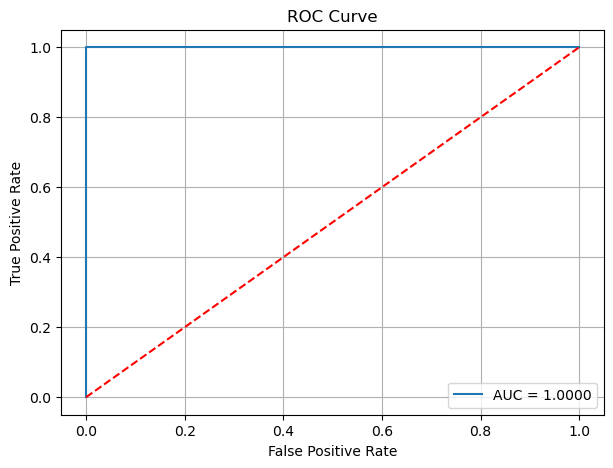

In [3]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

y_prob = model.predict_proba(X_test)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

auc = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(7,5))

plt.plot(fpr, tpr, label=f"AUC = {auc:.4f}")

plt.plot([0,1],[0,1],'r--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.grid(True)

plt.show()

3. Plot the Precision-Recall curve for your model using sklearn.metrics.precision_recall_curve and matplotlib, and explain in one line why this curve is useful for imbalanced datasets.<br><br><em><strong>Hint:</strong> Focus on how precision and recall behave when the positive class is rare.</em>


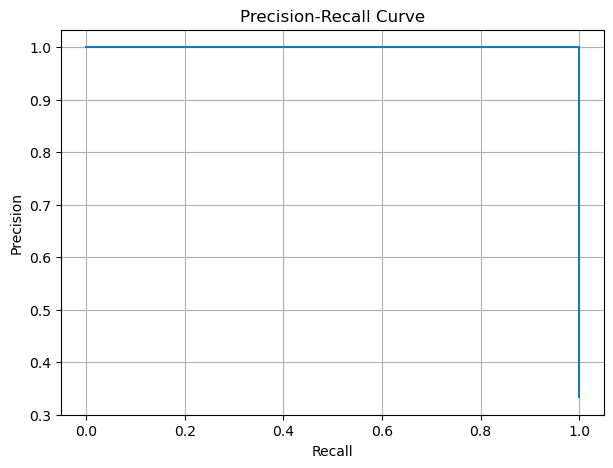

In [4]:
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(
    y_test,
    y_prob
)

plt.figure(figsize=(7,5))

plt.plot(recall, precision)

plt.xlabel("Recall")
plt.ylabel("Precision")

plt.title("Precision-Recall Curve")

plt.grid(True)

plt.show()

4. Calculate the log loss (cross-entropy loss) for your test set predictions using sklearn.metrics.log_loss and print the result.


In [5]:
from sklearn.metrics import log_loss

loss = log_loss(y_test, y_prob)

print("Log Loss:", loss)

Log Loss: 6.093038013556105e-07
